In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly as ps

# 1. Load & First Look

In [3]:
df=pd.read_csv('../data/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
623,624,0,3,"Hansen, Mr. Henry Damsgaard",male,21.0,0,0,350029,7.8542,NaN,S
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9000,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
400,401,1,3,"Niskanen, Mr. Juha",male,39.0,0,0,STON/O 2. 3101289,7.9250,NaN,S


In [6]:
df.shape

(891, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# Stats for Numerical Columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# Stats for Categorical Columns
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [10]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [12]:
## Survuved -------> target column

In [13]:
## Observations:::::
## 1: Correlations with Survived-----
 ##                           Pclass (−0.338): Moderate negative correlation – 
 ##                            lower class is associated with lower survival. First-class passengers had better chances.

 ##                            Fare (0.257): Positive correlation – people who paid higher fares survived  more
 ##                            Age (−0.077): Very weak negative – older passengers slightly less likely to survive.

In [14]:
# Pclass & Fare are highy correlated

# 2. Understand Your Columns

In [15]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [16]:
# df.columns.tolist()

In [17]:
# Unique values per column
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [18]:
# Observations:::::
# Now we can identify different types of data in the columns

#     1: Numerical Columns
#         Continuous data(columns)......... Age, Fare, 
#         Discrete ........................ PassengerId, SibSp, Parch

#     2. Categorical Columns
#         Ordinal............ Pclass
#         Nominal............ Sec, Embarked Ticket, Cabin, Name
#         Binary............ . Survived (nominal by default)

# 3. Missing Value Analysis

In [19]:
# df.duplicated()
df.duplicated().value_counts()

False    891
Name: count, dtype: int64

In [20]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [21]:
# using list comprehension to identify names of columns with null values
[features for features in df.columns if df[features].isnull().sum() > 0 ]

['Age', 'Cabin', 'Embarked']

In [22]:
missing=df.isnull().sum()
missing_pct= ( missing / len(df) )* 100

In [23]:
missing_df=pd.DataFrame({
    'missing_count':missing,
    'missing_pct':missing_pct
}).sort_values('missing_pct', ascending=False)

In [24]:
print(missing_df[missing_df.missing_count > 0])

          missing_count  missing_pct
Cabin               687    77.104377
Age                 177    19.865320
Embarked              2     0.224467


In [25]:
# Visualizing missing values

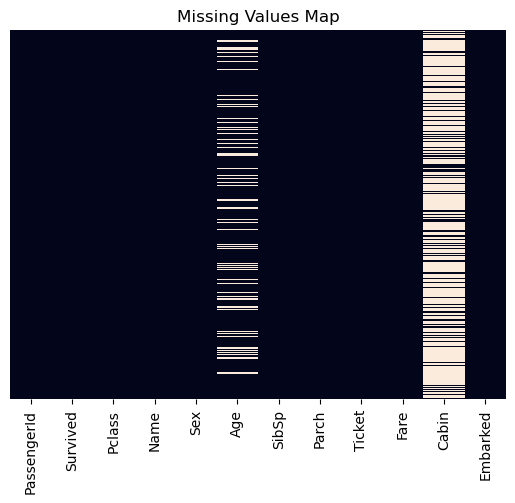

In [26]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Map')
plt.savefig('Missing Values Map.png')
plt.show()

In [27]:
# Observations
# Age has 177 null values and about 19%
# Cabin has 687 missing values which makes 77% 
# Emarked with 2 null valuse ....0.2%

In [28]:
# Decision rules:

# < 5% missing → impute (mean/median/mode)
# 5–30% missing → impute with caution or add indicator column


# 50% missing → consider dropping the column


# Investigate if missingness is random (MAR) or systematic (MNAR)

## Handling Missing Values

### Embarked 

In [29]:
# Embarked 
mode_emb=df['Embarked'].mode()[0]
print(mode_emb)



S


In [30]:
df['Embarked'] = df['Embarked'].fillna(mode_emb)

In [31]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

### Age

In [32]:
# Age  -----> Age (19% missing) → impute with median + create an indicator column ....> (Age_Missing)
df['Age_Missing'] = df['Age'].isnull().astype(int)


In [33]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Missing
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [34]:
# Impute missing Age with median
median_age=df['Age'].median()
df['Age']=df['Age'].fillna(median_age)

In [35]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Missing      0
dtype: int64

### Cabin

In [36]:
# Cabin (77% missing) ......> Dropping the column 
df.drop('Cabin', axis=1, inplace=True)

In [37]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_Missing
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [38]:
# empty list as all null are computed and replaced
[f for f in df.columns if df[f].isnull().sum() > 0]

[]

# 4. Distribution Analysis — Numerical Features

In [39]:
# num_cols=df.select_dtypes(include=np.number). columns
# print(num_cols)
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

## Histograms

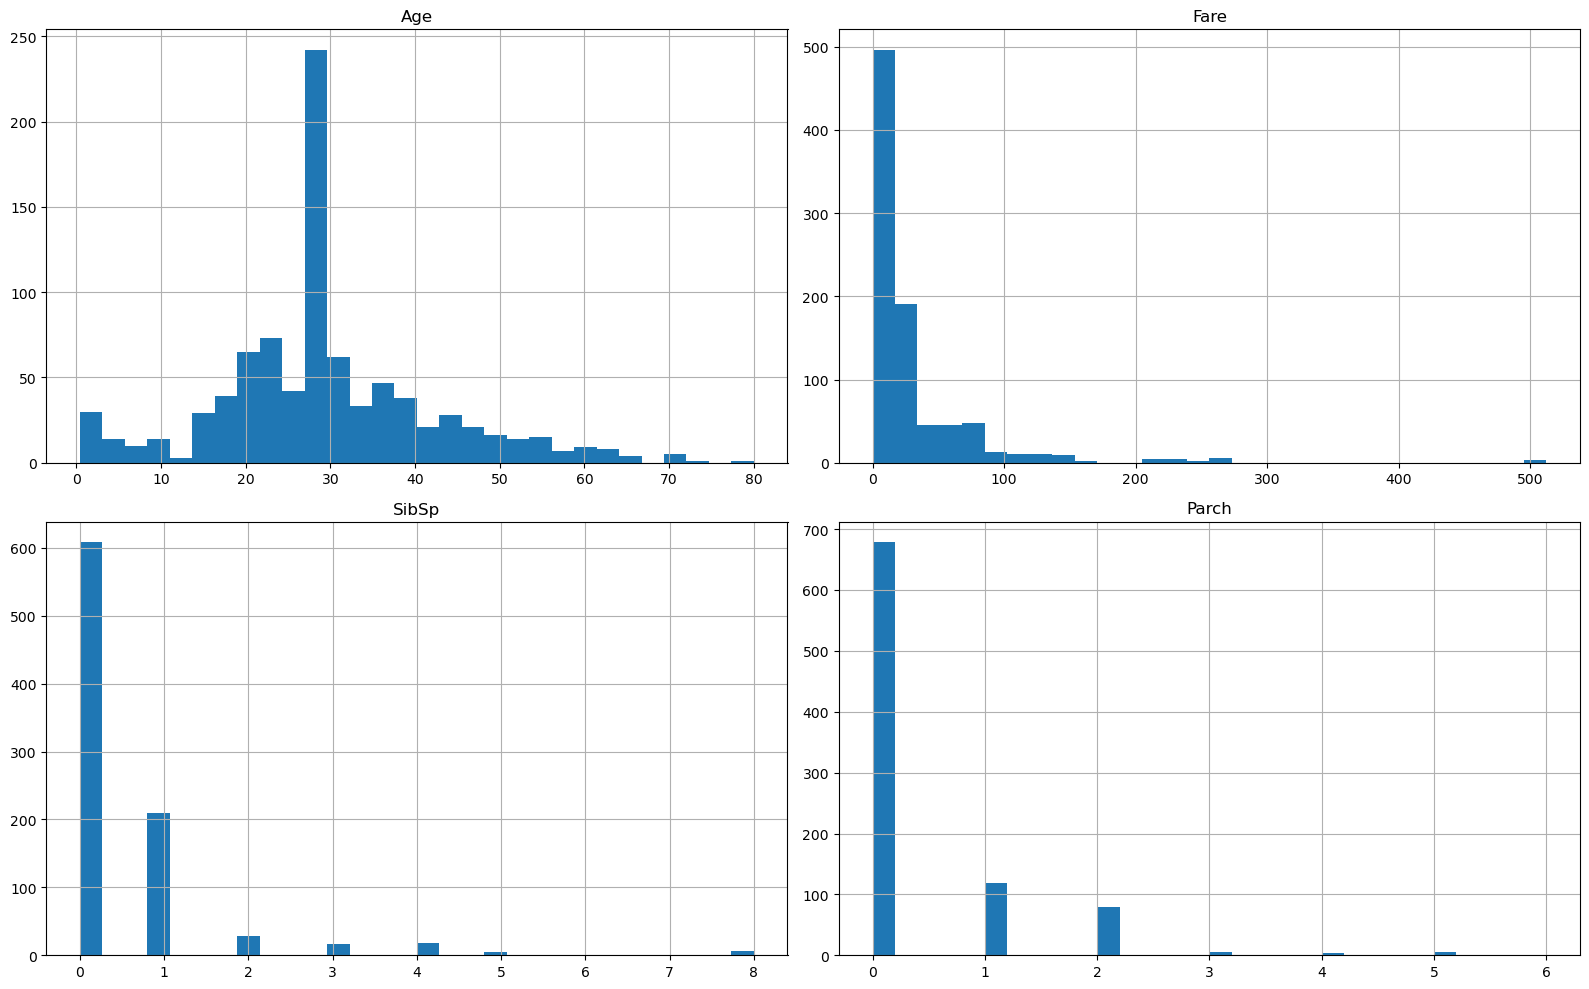

In [40]:

df[num_cols].hist(figsize=(16,10), bins=30)
plt.tight_layout()
plt.savefig('Numerical Data with Histogram.png')
plt.show()

## Boxplots for Outliers

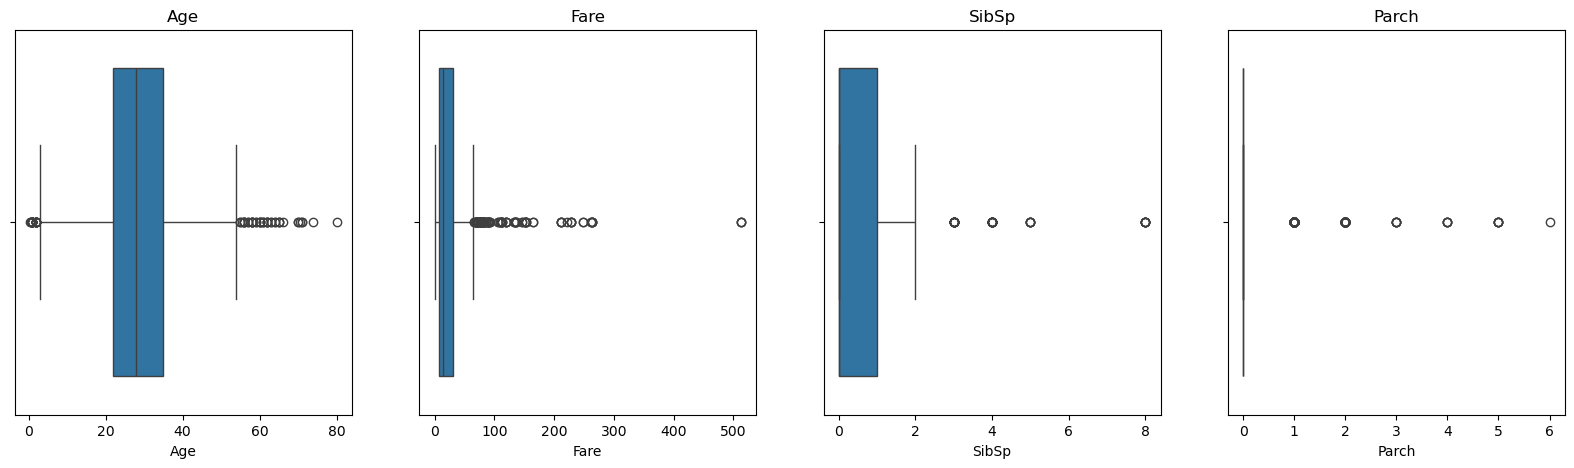

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

In [41]:

n_cols = len(num_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))  # 5 inches wide per subplot
if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax)
    plt.figure(figsize=(10,10))
    ax.set_title(col)

plt.tight_layout()
plt.savefig('Outliers with Box Plots.png')
plt.show()

### Checking Skewness

In [42]:

print(df[num_cols].skew().sort_values(ascending=False))

Fare     4.787317
SibSp    3.695352
Parch    2.749117
Age      0.510245
dtype: float64


### Visualizing Skewness

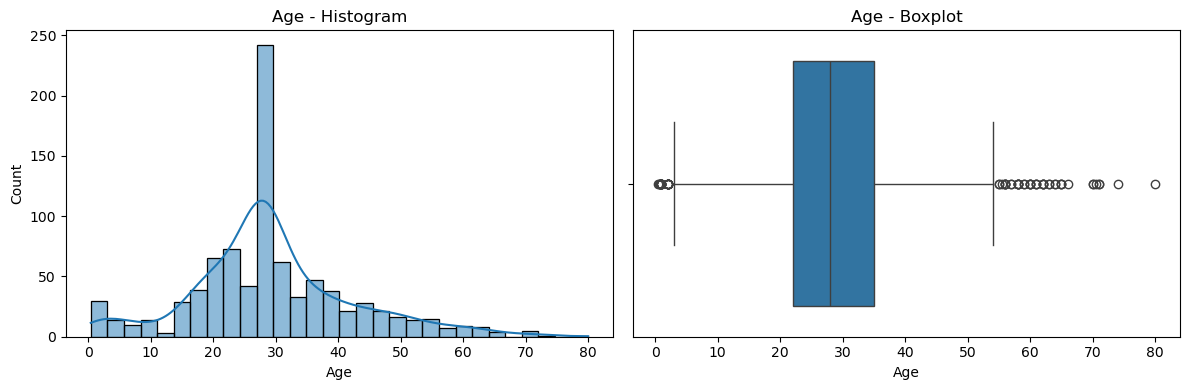

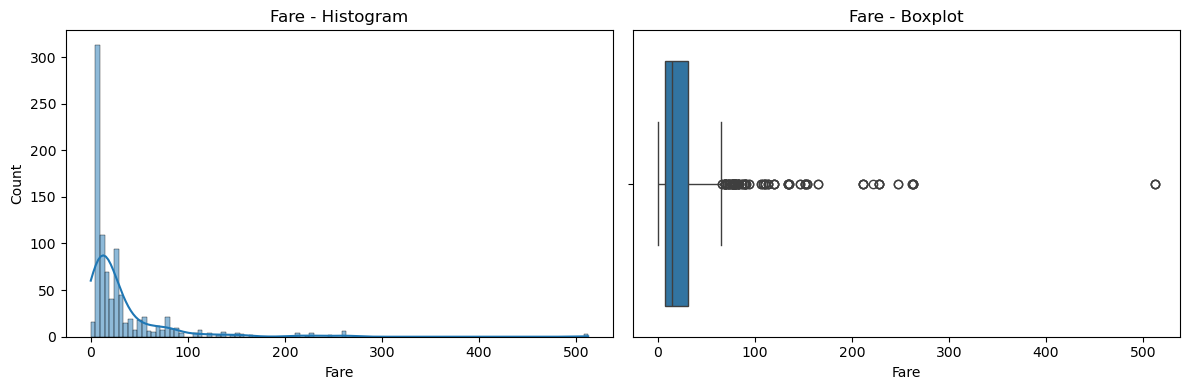

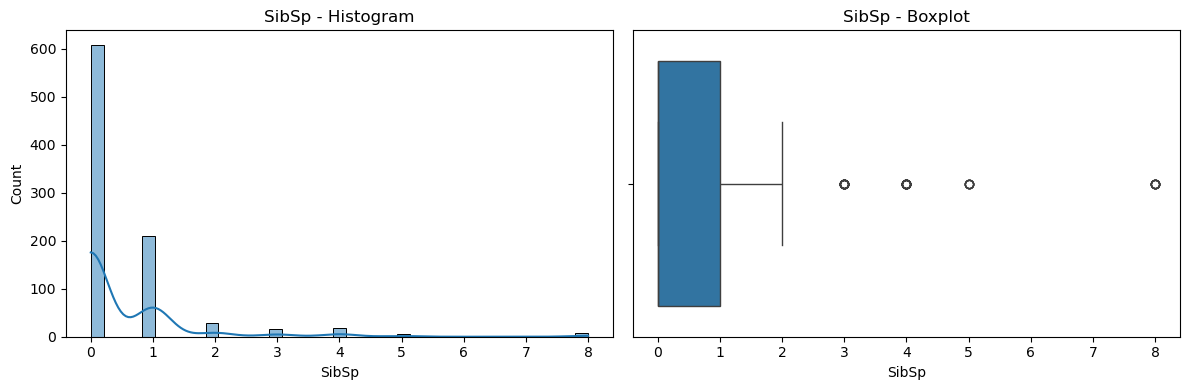

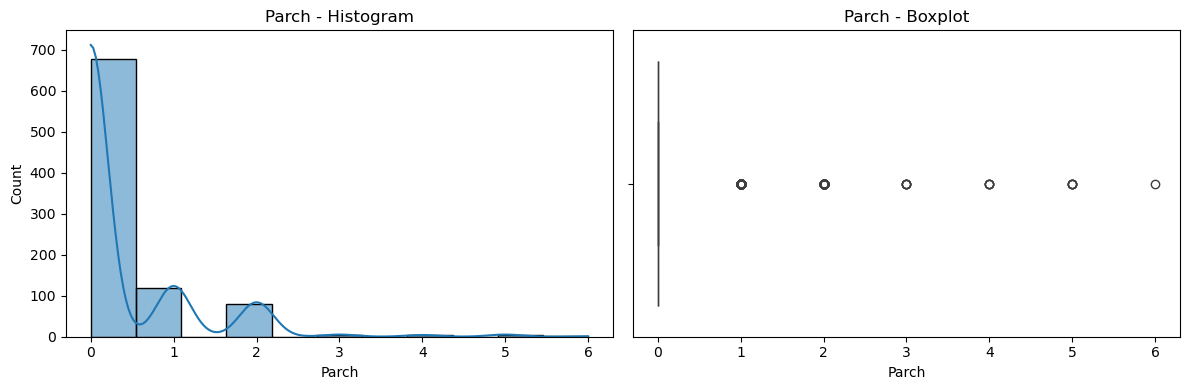

In [43]:

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col} - Histogram')
    
    # Boxplot to see outliers
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} - Boxplot')
    
    plt.tight_layout()
    plt.savefig('Skewness with Hist and Box plots.png')
    plt.show()

In [44]:
print(df[num_cols].skew().sort_values(ascending=False))

Fare     4.787317
SibSp    3.695352
Parch    2.749117
Age      0.510245
dtype: float64


In [45]:
# What to look for:

# Skewness > 1 or < -1 → consider log/sqrt transform
# Bimodal distribution → possible hidden subgroup
# Very narrow range → low variance, possibly useless

In [46]:
# Log transformation ------>  Fare column  (as skew = 4 )
df['Fare_log']=np.log1p(df['Fare'])

# use "Fare_log" in models instead of original Fare"

In [47]:
#Log transform (for mild improvement) as they tend to fall in 0 to 6 range .....> this transformation results in fewer improvemnet,
# but there are other ways as below........> For now I will use log transformation for both SibSp and Parch

df['SibSp_log'] = np.log1p(df['SibSp'])
df['Parch_log'] = np.log1p(df['Parch'])
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [150]:
# Square root transform (milder than log)  ---> much better than log but still not effiecient

# df['SibSp_sqrt'] = np.sqrt(df['SibSp'])
# df['Parch_sqrt'] = np.sqrt(df['Parch'])

In [152]:
# We organize Bin into categorical groups

# df['SibSp_bin']= pd.cut( df['SibSp'], bins=[-1, 0, 1, 2, 100], labels=['0', '1', '2', '3+'])
# df['Parch_bin']=pd.cut( df['Parch'], bins=[-1, 0, 1, 2, 100], labels=['0', '1', '2', '3+'])

In [48]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_Missing,Fare_log,SibSp_log,Parch_log
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2.110213,0.693147,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0,4.280593,0.693147,0.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,2.188856,0.000000,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0,3.990834,0.693147,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,2.202765,0.000000,0.0


In [163]:
# Checking Skewness after transformation
print(df[['Fare_log', 'SibSp_log', 'Parch_log']] .skew())


# reduced much...> But we can also reduced it by using other 2 method i discussed above

Fare_log     0.394928
SibSp_log    1.661245
Parch_log    1.675439
dtype: float64


In [ ]:
# Now Again Visualizing 

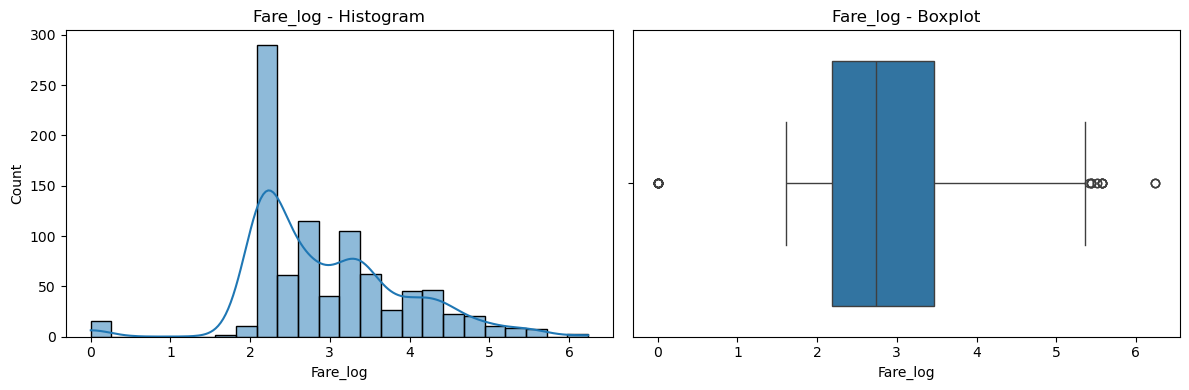

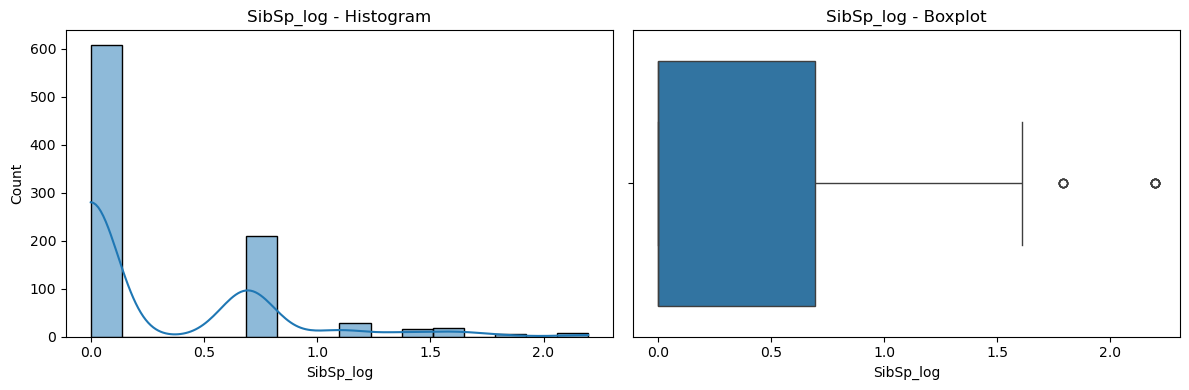

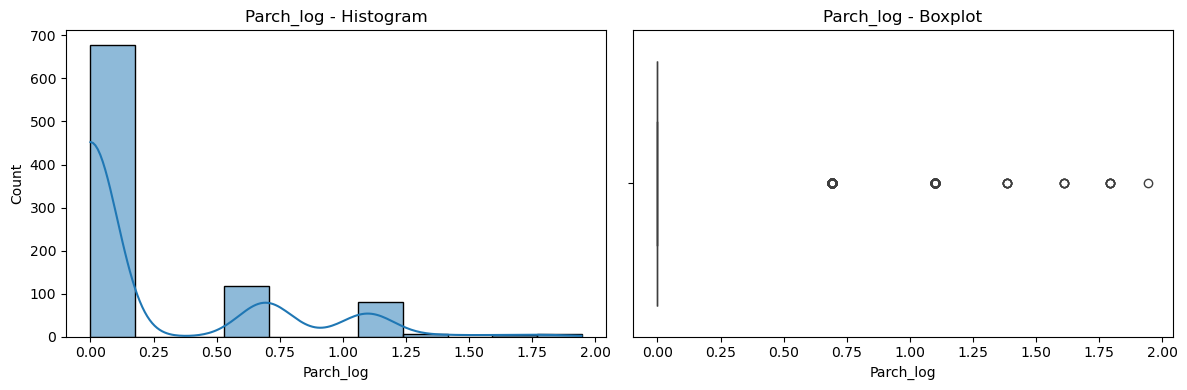

In [49]:
for col in df[['Fare_log', 'SibSp_log', 'Parch_log']]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col} - Histogram')
    
    # Boxplot to see outliers
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} - Boxplot')
    
    plt.tight_layout()
    plt.savefig('Skewness after Transformation.png')
    plt.show()

# 5. Distribution Analysis — Categorical Features

In [50]:
cat_col= df.select_dtypes(include='object').columns
cat_col

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

In [51]:
cat_cols=df[['Sex', 'Embarked']].columns
cat_cols

Index(['Sex', 'Embarked'], dtype='object')

Sex
male      577
female    314
Name: count, dtype: int64


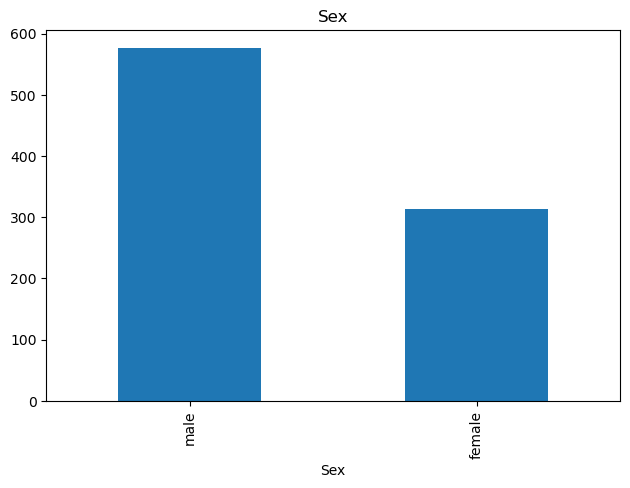

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


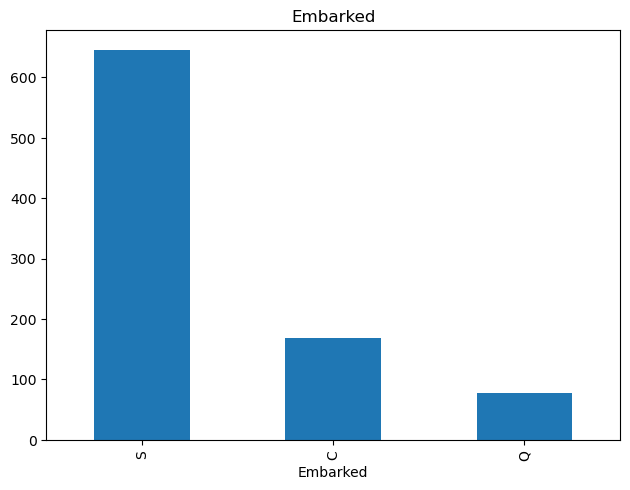

In [53]:
for col in cat_cols:
    print(df[col].value_counts())
    df[col].value_counts().plot(kind="bar")
    plt.tight_layout()
    plt.title(col)
    plt.savefig('Categorical Features with Barplot.png')
    plt.show()

In [190]:
# What to look for:

# High cardinality (100s of unique values) → needs special encoding
# Dominant class (> 90%) → near-constant, low predictive value
# Rare categories → may need grouping into "Other"

In [54]:
for col in cat_cols:
    value_counts = df[col].value_counts()
    n_unique = len(value_counts)
    most_common_pct = value_counts.iloc[0] / len(df) * 100
    print(n_unique)
    print(most_common_pct)
    print()
 

2
64.75869809203144

3
72.50280583613917



In [191]:
# Observations
# First column: 2 unique values, most common = ~65% → not dominant (>90% threshold), low cardinality.

# Second column: 3 unique values, most common = ~73% → also fine.

# 6. Outlier Detection

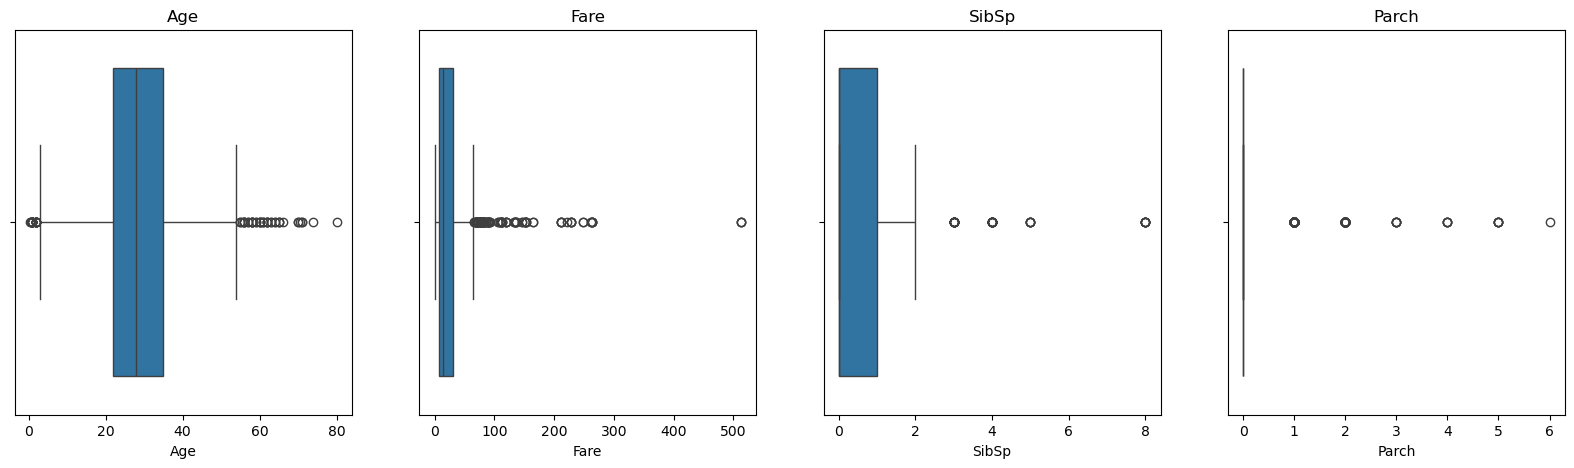

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

In [232]:
# Box Plot

n_cols = len(num_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))  
if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax)
    plt.figure(figsize=(10,10))
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [55]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

Age: 66 outliers (7.4%)
Fare: 116 outliers (13.0%)
SibSp: 46 outliers (5.2%)
Parch: 213 outliers (23.9%)


In [194]:
# # Decision: Are they errors (remove/cap) or genuine extremes (keep, use robust models)?

# None of these outliers are data errors.

# For Parch, ignore the IQR‑based “outlier” label – it’s a false positive due to zero inflation. Use binning or tree models. 

#  For Fare, use log transform. 

# For Age and SibSp, keep as is or bin.


In [ ]:
# Observations::::# 

#In my case these are genuine extreme, so 
# I will keep them and use Robust Model... Another thing I can do is
# log transformation and binning which i have alredy done


# 7. Correlation Analysis

In [57]:
num_columns=df[['Survived','Pclass','Age','SibSp','Parch', 'Fare']].columns

In [58]:
corr = df[num_columns].corr()
# corr

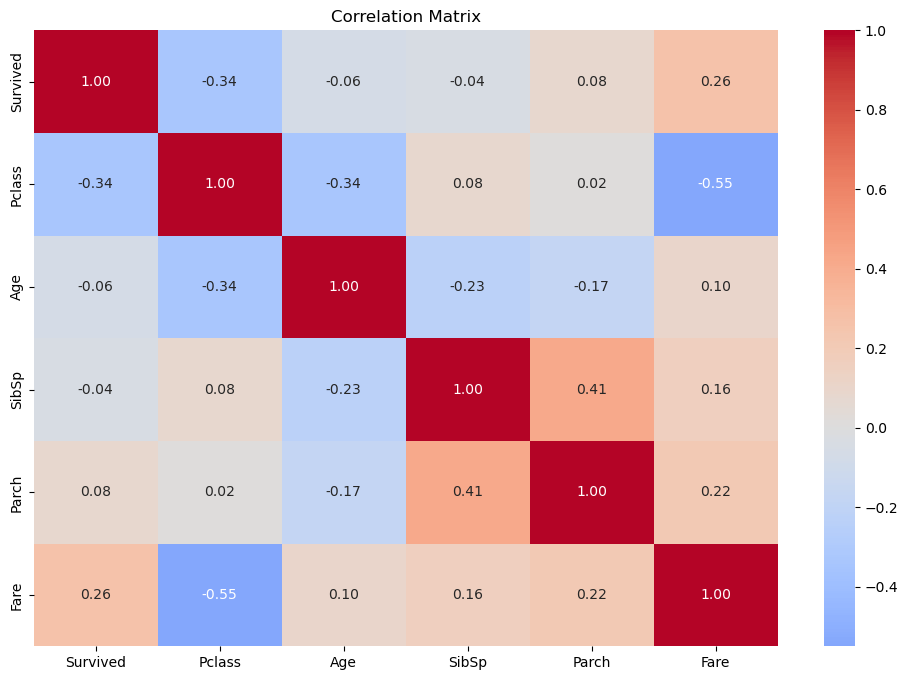

In [59]:
#Heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.savefig('Heatmap for Correlation.png')
plt.show()

In [60]:
# Find highly correlated pairs

# we can ajust threshold 

threshold = 0.85
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > threshold:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(high_corr)

[]


# 8. Target Variable Analysis

In [61]:
target='Survived'

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


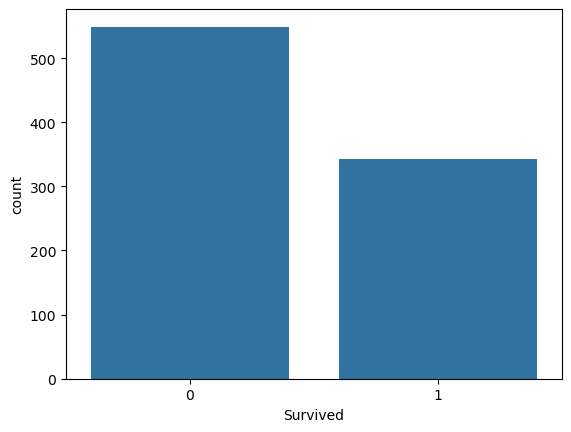

In [63]:
# Classification — class balance---------------------> Count Plot

print(df[target].value_counts(normalize=True))
sns.countplot(x=target, data=df)
plt.savefig('Target with countplot.png')

Skewness: 0.479


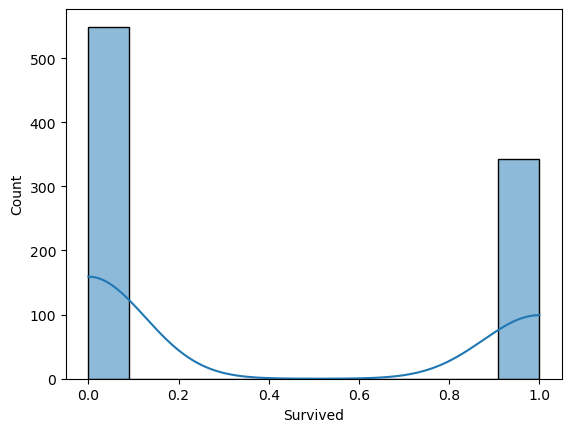

In [64]:
# Regression — distribution of target ----------------------> Histogram with kernal density estimation

sns.histplot(df[target], kde=True)
plt.savefig('Regression of target with Histogram.png')
print(f"Skewness: {df[target].skew():.3f}")


In [236]:
# Feature vs. target

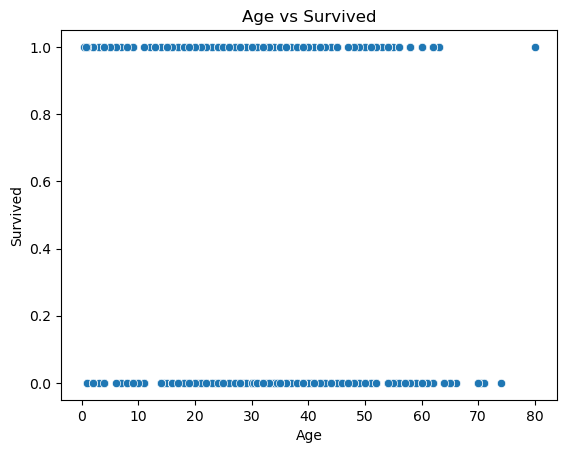

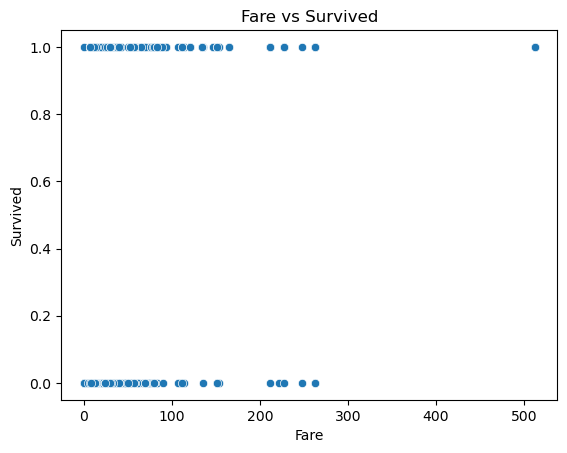

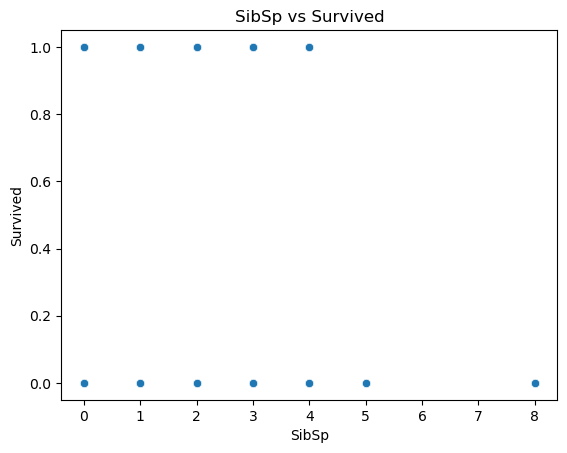

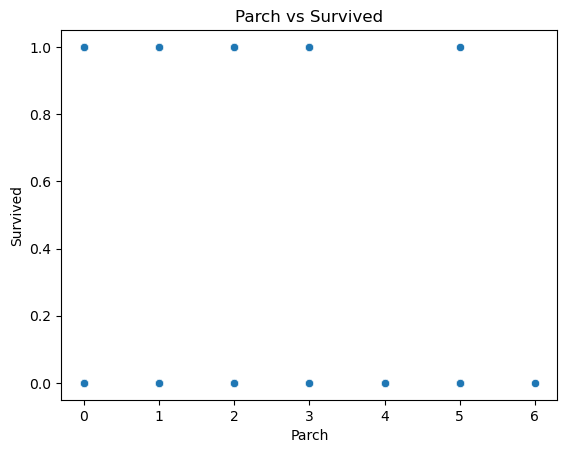

In [235]:
for col in num_cols:
    if col != target:
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.show()
        

# 9. Bivariate & Multivariate Analysis

### Pairplot — relationships between all numerical features

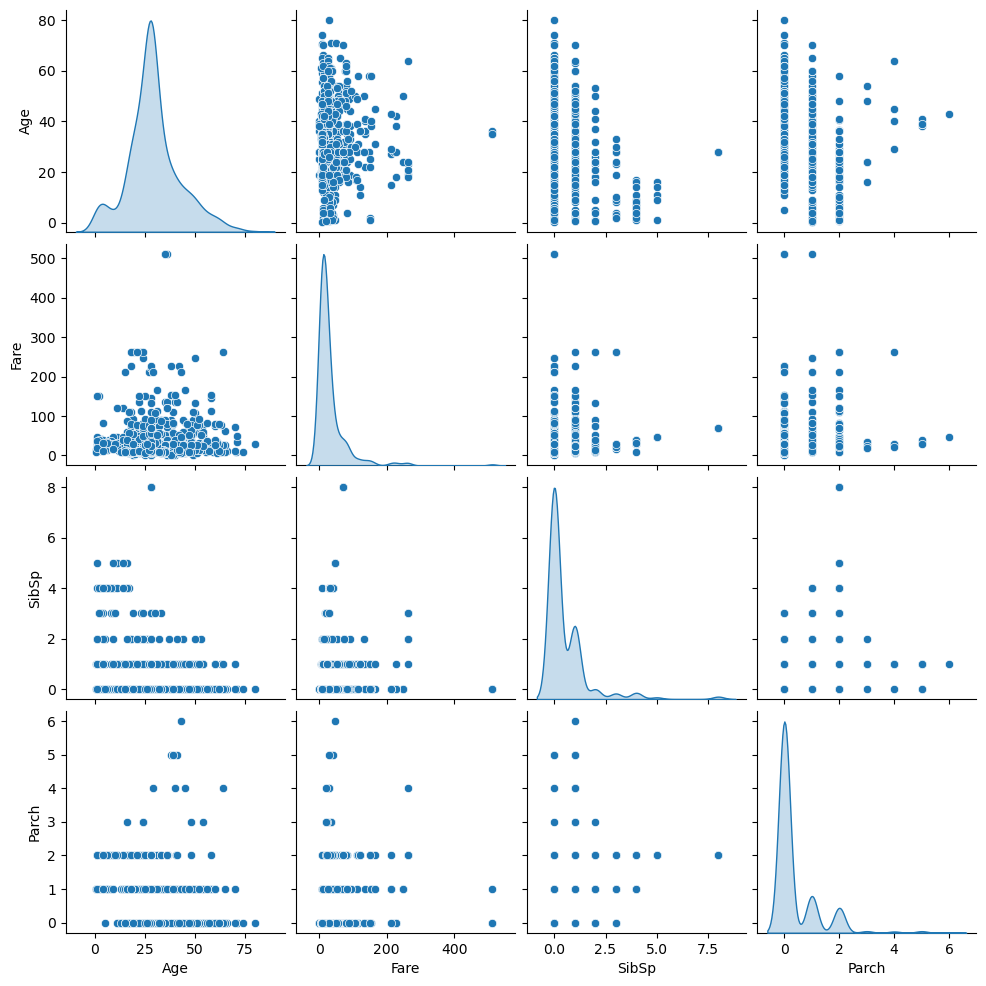

In [65]:
sns.pairplot(df[num_cols], diag_kind="kde")
plt.savefig('Pairplot for Numerical features.png')

### Categorical vs numerical target

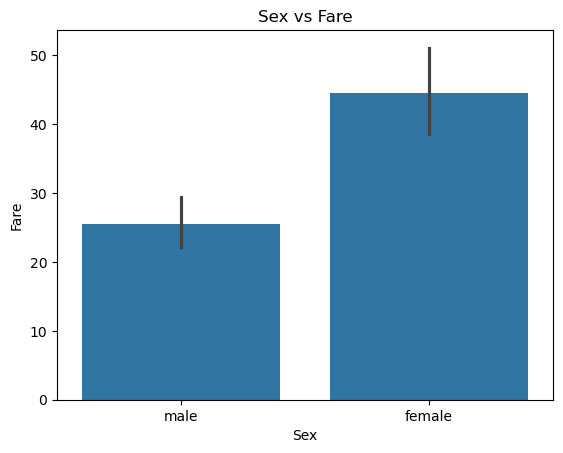

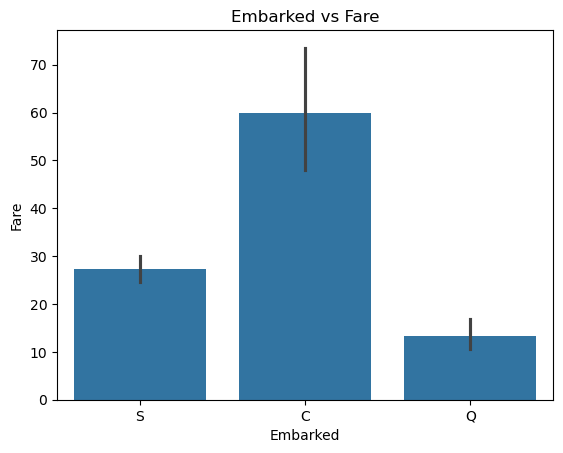

,Age,Fare,SibSp,Parch
Fare,,,,
0.0000,31.333333,0.0000,0.00,0.000000
4.0125,20.000000,4.0125,0.00,0.000000
5.0000,33.000000,5.0000,0.00,0.000000
6.2375,61.000000,6.2375,0.00,0.000000
6.4375,34.500000,6.4375,0.00,0.000000
...,...,...,...,...
227.5250,31.500000,227.5250,0.25,0.000000
247.5208,37.000000,247.5208,0.00,1.000000
262.3750,19.500000,262.3750,2.00,2.000000


In [66]:
# Similarly we can set any numerical columns as target and use scatterplot, boxplot,  barplot

target='Fare'
for col in cat_cols:
    sns.barplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
    plt.savefig(f'{col} vs {target}.png')
    plt.show()
    

df.groupby(target)[num_cols].mean()

## Categorical vs categorical

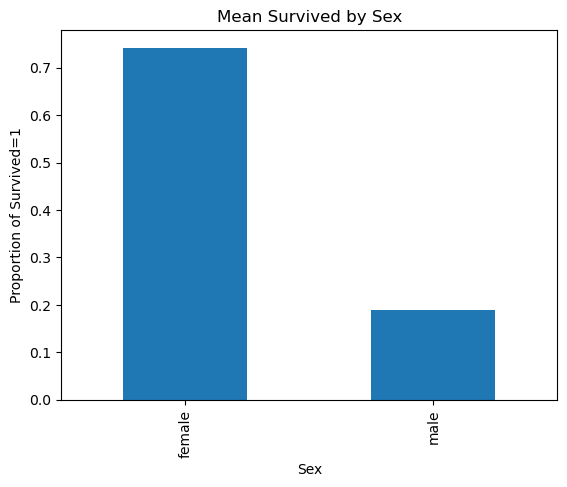

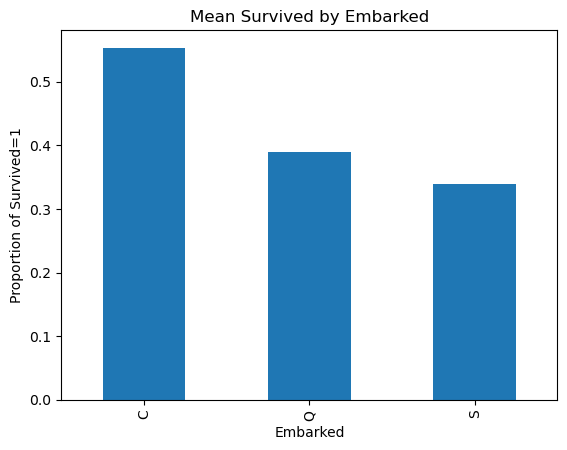

In [69]:
target='Survived'
for col in cat_cols:
    df.groupby(col)[target].mean().plot(kind='bar')
    plt.title(f'Mean {target} by {col}')
    plt.ylabel(f'Proportion of {target}=1')
    plt.savefig(f'Categorical {target} by {col}.jpeg')
    plt.show()

In [240]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_Missing,Fare_log,SibSp_log,Parch_log
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2.110213,0.693147,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0,4.280593,0.693147,0.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,2.188856,0.000000,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0,3.990834,0.693147,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,2.202765,0.000000,0.0


 # Pro Tip


In [ ]:
# Automate the boring parts with profiling libraries for a quick first pass:

In [241]:
# ydata-profiling (formerly pandas-profiling)
from ydata_profiling import ProfileReport
ProfileReport(df, title="EDA Report").to_file("report.html")

# # sweetviz — great for comparing train/test
# import sweetviz as sv
# sv.analyze(df).show_html("eda.html")

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_21724\3911599155.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 127.24it/s]A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# End